<a href="https://colab.research.google.com/github/gkrao-23/fake_news_detection_system/blob/main/fake_news_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers
!pip install datasets
!pip install scikit-learn
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install torch

In [ ]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 1
true["label"] = 0
df = pd.concat([fake, true])
df["content"] = df["title"] + " " + df["text"]
df = df[["content","label"]]
df

,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1
...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,0
21413,LexisNexis withdrew two products from Chinese ...,0
21414,Minsk cultural hub becomes haven from authorit...,0
21415,Vatican upbeat on possibility of Pope Francis ...,0


In [ ]:
df.head()

,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1


In [ ]:
df.shape

(44898, 2)

In [ ]:
df.columns

Index(['content', 'label'], dtype='object')

In [ ]:
df.isnull().sum()


,0
content,0
label,0


In [ ]:
df['label'].value_counts()

,count
label,
1,23481
0,21417


In [ ]:
df.head(10)

,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1
5,Racist Alabama Cops Brutalize Black Boy While...,1
6,"Fresh Off The Golf Course, Trump Lashes Out A...",1
7,Trump Said Some INSANELY Racist Stuff Inside ...,1
8,Former CIA Director Slams Trump Over UN Bully...,1
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,1


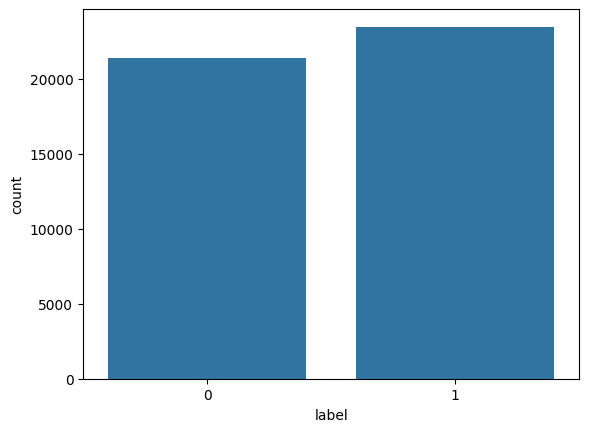

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.show()

**Dataset summary**


Columns: title, text, subject, date

concatenated fake and real news dataset

Total samples: 44898

Label Distribution:

Fake News (1): 23,481 samples  
Real News (0): 21,417 samples

Dataset is nearly balanced.

There were no Missing values.

In [ ]:
import torch
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["content"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [ ]:
print(len(train_texts))
print(len(val_texts))

35918
8980


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [ ]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding="max_length",
    max_length=256
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding="max_length",
    max_length=256
)

In [ ]:
print(train_encodings['input_ids'][0])

[101, 2287, 2590, 7155, 3160, 2339, 3031, 4023, 1012, 3746, 2851, 3251, 2245, 2698, 2436, 3829, 2067, 3056, 2444, 2064, 2702, 4496, 3497, 3786, 2274, 2250, 4685, 2092, 2426, 2167, 7325, 7823, 4608, 2313, 3447, 2317, 2501, 4608, 4507, 2715, 2894, 2617, 2309, 2744, 3392, 2283, 4287, 1998, 2000, 2684, 3514, 2092, 2004, 4366, 2408, 3399, 2381, 2149, 3116, 6592, 2082, 2707, 2738, 3168, 2045, 2593, 3361, 2041, 2455, 2364, 3447, 2192, 2974, 2898, 2283, 2037, 3716, 3465, 3046, 2664, 2036, 3806, 3026, 5587, 2932, 2395, 2604, 2613, 4639, 2611, 3649, 2342, 2312, 2612, 2311, 5769, 2369, 2064, 2034, 3749, 2326, 2028, 3599, 2367, 3154, 4595, 3112, 4031, 3298, 8013, 3233, 2562, 5333, 3942, 2256, 2718, 3147, 5466, 2430, 3800, 2379, 2492, 3185, 2274, 7929, 13180, 5258, 2488, 2658, 5136, 3959, 3347, 2486, 3638, 2994, 1037, 3635, 4025, 2429, 2302, 14396, 2096, 2933, 2130, 3265, 2136, 2224, 6739, 3328, 3086, 2607, 2242, 2030, 2664, 4638, 2598, 3110, 3113, 2012, 2659, 3329, 3125, 2312, 5454, 2402, 2963, 21

In [ ]:
class FakeNewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = FakeNewsDataset(train_encodings, train_labels.tolist())
val_dataset = FakeNewsDataset(val_encodings, val_labels.tolist())

In [ ]:
sample = train_dataset[0]

for key, value in sample.items():
    print(key, value.shape)

input_ids torch.Size([256])
token_type_ids torch.Size([256])
attention_mask torch.Size([256])
labels torch.Size([])


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    learning_rate=3e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_dir="./logs",

    load_best_model_at_end=True,

    weight_decay=0.01
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
print(train_dataset[0])

{'input_ids': tensor([  101,  4977,  1005,  1055,  9413, 16168,  2319,  2758,  1057,  1012,
         1055,  1012,  6744,  3247, 12517, 21112,  2006,  2375,  7571,  1006,
        26665,  1007,  1011,  5037,  2343, 28117, 10139,  2361,  9413, 16168,
         2319,  2056,  2006,  9432,  2008,  1057,  1012,  1055,  1012,  2343,
         6221,  8398,  1055, 15140,  3247,  2000,  6807,  6744,  2004,  1996,
         3007,  1997,  3956,  2001, 12517, 14353,  2006,  2248,  4277,  1012,
         9413, 16168,  2319,  4092,  1999,  7571,  2044,  7566,  2007,  3539,
         2704, 13573, 24529, 11514,  8180,  1010,  2036,  2056,  4977,  2359,
         2000,  2156,  1037,  9879,  5576,  2006,  1996,  2479,  1997,  9719,
         1010,  2021,  2056,  3306, 18543,  2015,  2020,  9992,  7566,  1012,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0, 

In [ ]:
print(df["content"].iloc[0])

 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this d

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.003681,0.000984,0.999777,0.999789,0.999578,1.000000
2,0.002102,0.000318,0.999889,0.999894,0.999789,1.000000
3,0.000005,0.000003,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=6735, training_loss=0.004166998497453126, metrics={'train_runtime': 2917.7123, 'train_samples_per_second': 36.931, 'train_steps_per_second': 2.308, 'total_flos': 7136946037389312.0, 'train_loss': 0.004166998497453126, 'epoch': 3.0})

In [ ]:
trainer.save_model("fake_news_model")
tokenizer.save_pretrained("fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_model/tokenizer_config.json', 'fake_news_model/tokenizer.json')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

trainer.save_model("/content/drive/MyDrive/fake_news_model")
tokenizer.save_pretrained("/content/drive/MyDrive/fake_news_model")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/fake_news_model/tokenizer_config.json',
 '/content/drive/MyDrive/fake_news_model/tokenizer.json')

In [ ]:
trainer.evaluate()

{'eval_loss': 3.1064762424648507e-06,
 'eval_accuracy': 1.0,
 'eval_f1': 1.0,
 'eval_precision': 1.0,
 'eval_recall': 1.0,
 'eval_runtime': 68.5183,
 'eval_samples_per_second': 131.06,
 'eval_steps_per_second': 8.202,
 'epoch': 3.0}

In [ ]:
predictions = trainer.predict(val_dataset)

In [ ]:
preds = predictions.predictions.argmax(axis=1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4247
           1       1.00      1.00      1.00      4733

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_labels, preds)
print(cm)

[[4247    0]
 [   0 4733]]


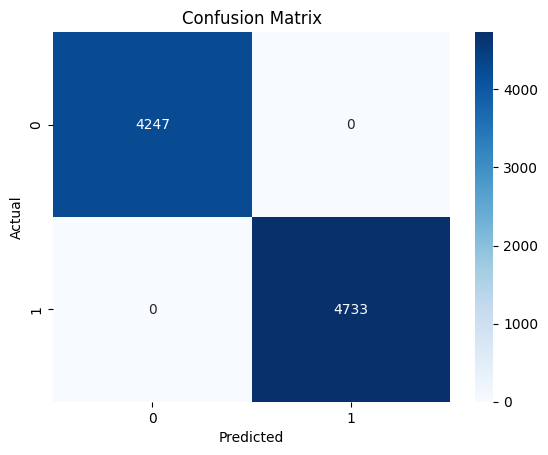

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
wrong_predictions = []

for text, true_label, pred_label in zip(val_texts, val_labels, preds):
    if true_label != pred_label:
        wrong_predictions.append((text, true_label, pred_label))

len(wrong_predictions)

0

In [ ]:
!pip install gradio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/fake_news_model")
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/fake_news_model")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
import torch

def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    pred = torch.argmax(probs).item()

    if pred == 0:
        return "Real News"
    else:
        return "Fake News"

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(lines=5, placeholder="Enter news text here"),
    outputs="text",
    title="Fake News Detection using DistilBERT"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5fb2a85f65e8df7f68.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
